# Yaw Angle Pattern Classifier

## Overview

This notebook implements machine learning models to classify yaw angle patterns from head movements. The task is to distinguish dynamic, varying yaw sequences from static or near-static ones.

We implement and compare two approaches:
1. **Traditional ML with Engineered Features** - Random Forest classifier using statistical features
2. **Deep Learning Approach** - 1D CNN/LSTM model that learns patterns directly from raw sequences

## Features Used
* __Number of Peaks__: Count of local maxima in the sequence
* __Number of Troughs__: Count of local minima in the sequence
* __Amplitude__: Difference between maximum and minimum yaw angles
* __Average Yaw__: Mean yaw angle across the sequence
* __Yaw Range__: Range (maximum - minimum) of yaw angles
* __Standard Deviation__: Variation of yaw angles

## Import the necessary dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

# For traditional ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# For deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load Raw Data

We'll load the raw data from data.npy and labels.npy files.

In [5]:
# Load the raw data
X_raw = np.load('../../datasets/classifier/classifier_manual_data.npy')
y_raw = np.load('../../datasets/classifier/classifier_manual_labels.npy')

print(f"X_raw shape: {X_raw.shape}")
print(f"y_raw shape: {y_raw.shape}")

X_raw shape: (40000, 60, 2)
y_raw shape: (40000,)


## Define Feature Calculation Functions

Implement functions to extract features from raw yaw angle sequences.

In [6]:
def getFeatureVectorWithLabel(raw_data, labels):
    """
    Calculate engineered features from raw yaw angle sequences and include labels.
    
    Parameters:
    raw_data (np.ndarray): Raw data array of shape (n_samples, sequence_length, 2)
                          where the second dimension contains [time, yaw]
    labels (np.ndarray): Labels for each sample
    
    Returns:
    pd.DataFrame: DataFrame containing the calculated features and labels
    """
    # Extract the yaw values (in dimension 1, index 1)
    yaw_values = raw_data[:, :, 1]
    
    num_peaks_list = []
    num_troughs_list = []
    amplitude_peaks_list = []
    average_yaw_list = []
    yaw_range_list = []
    std_yaw_list = []

    for i, row in enumerate(yaw_values):
        # Find peaks and troughs in the yaw sequence
        peaks, _ = find_peaks(row)
        troughs, _ = find_peaks(-row)

        # Calculate features
        num_peaks = len(peaks)
        num_troughs = len(troughs)
        
        # Handle case when there are no peaks or troughs
        if peaks.size > 0 and troughs.size > 0:
            amplitude_peaks = row[peaks].max() - row[troughs].min()
        else:
            amplitude_peaks = np.nan
            
        average_yaw = np.mean(row)
        yaw_range = np.ptp(row)  # Peak-to-peak range
        std_yaw = np.std(row)

        # Append to lists
        num_peaks_list.append(num_peaks)
        num_troughs_list.append(num_troughs)
        amplitude_peaks_list.append(amplitude_peaks)
        average_yaw_list.append(average_yaw)
        yaw_range_list.append(yaw_range)
        std_yaw_list.append(std_yaw)

    # Create DataFrame
    df = pd.DataFrame({
        'num_peaks': num_peaks_list,
        'num_troughs': num_troughs_list,
        'amplitude_peaks': amplitude_peaks_list,
        'average_yaw': average_yaw_list,
        'yaw_range': yaw_range_list,
        'std_yaw': std_yaw_list,
        'label': labels
    })
    
    return df

def getFeatureVector(raw_data):
    """
    Calculate engineered features from raw yaw angle sequences without labels.
    
    Parameters:
    raw_data (np.ndarray): Raw data array of shape (n_samples, sequence_length, 2)
                          where the second dimension contains [time, yaw]
    
    Returns:
    pd.DataFrame: DataFrame containing the calculated features
    """
    # Extract the yaw values (in dimension 1, index 1)
    yaw_values = raw_data[:, :, 1]
    
    num_peaks_list = []
    num_troughs_list = []
    amplitude_peaks_list = []
    average_yaw_list = []
    yaw_range_list = []
    std_yaw_list = []

    for i, row in enumerate(yaw_values):
        # Find peaks and troughs in the yaw sequence
        peaks, _ = find_peaks(row)
        troughs, _ = find_peaks(-row)

        # Calculate features
        num_peaks = len(peaks)
        num_troughs = len(troughs)
        
        # Handle case when there are no peaks or troughs
        if peaks.size > 0 and troughs.size > 0:
            amplitude_peaks = row[peaks].max() - row[troughs].min()
        else:
            amplitude_peaks = np.nan
            
        average_yaw = np.mean(row)
        yaw_range = np.ptp(row)  # Peak-to-peak range
        std_yaw = np.std(row)

        # Append to lists
        num_peaks_list.append(num_peaks)
        num_troughs_list.append(num_troughs)
        amplitude_peaks_list.append(amplitude_peaks)
        average_yaw_list.append(average_yaw)
        yaw_range_list.append(yaw_range)
        std_yaw_list.append(std_yaw)

    # Create DataFrame
    df = pd.DataFrame({
        'num_peaks': num_peaks_list,
        'num_troughs': num_troughs_list,
        'amplitude_peaks': amplitude_peaks_list,
        'average_yaw': average_yaw_list,
        'yaw_range': yaw_range_list,
        'std_yaw': std_yaw_list
    })
    
    return df

In [7]:
# Calculate features from raw data
features_df = getFeatureVectorWithLabel(X_raw, y_raw)

# Check the first few rows
print("First few rows of calculated features:")
features_df.head()

First few rows of calculated features:


,num_peaks,num_troughs,amplitude_peaks,average_yaw,yaw_range,std_yaw,label
0,5,6,116.507202,-3.109567,116.507202,30.076874,1
1,8,8,102.896698,1.694295,102.896698,30.886007,1
2,9,10,140.318893,-2.527711,140.318893,41.622387,1
3,8,9,109.348846,-2.337143,109.348846,29.301565,1
4,6,7,126.551865,2.795934,126.551865,36.047012,1


In [8]:
# Handle missing values if any
print("Checking for missing values in the features:")
print(features_df.isnull().sum())

# Fill missing values if needed
features_df = features_df.fillna(0)

# Convert features to numpy arrays for modeling
X_features = features_df.drop('label', axis=1).to_numpy()
y_labels = features_df['label'].to_numpy()

# Define feature names
feature_names = ['num_peaks', 'num_troughs', 'amplitude_peaks', 'average_yaw', 'yaw_range', 'std_yaw']

print(f"\nFeatures shape: {X_features.shape}")
print(f"Labels shape: {y_labels.shape}")

Checking for missing values in the features:
num_peaks          0
num_troughs        0
amplitude_peaks    0
average_yaw        0
yaw_range          0
std_yaw            0
label              0
dtype: int64

Features shape: (40000, 6)
Labels shape: (40000,)


## Explore and Visualize the Data

Dataset statistics:
          num_peaks   num_troughs  amplitude_peaks   average_yaw  \
count  40000.000000  40000.000000     40000.000000  40000.000000   
mean      10.631000     11.053425        79.699112     -5.939132   
std        3.607785      3.519649        47.548889     17.889433   
min        4.000000      4.000000         3.665863    -76.037575   
25%        8.000000      8.000000        31.726021    -11.386058   
50%        9.000000     10.000000        96.377998     -3.073568   
75%       13.000000     13.000000       122.282072      0.745827   
max       23.000000     24.000000       155.472473     75.380615   

          yaw_range       std_yaw         label  
count  40000.000000  40000.000000  40000.000000  
mean      86.045082     24.170525      0.500000  
std       41.338459     11.939787      0.500006  
min        4.685345      1.020140      0.000000  
25%       53.838272     13.299132      0.000000  
50%       96.377998     27.104499      0.500000  
75%      122.2820

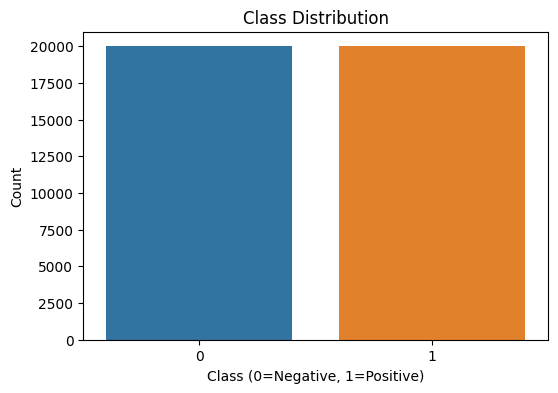

In [9]:
# Display some basic statistics
print("Dataset statistics:")
print(features_df.describe())

# Display class distribution
class_counts = features_df['label'].value_counts()
print("\nClass distribution:")
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=features_df)
plt.title('Class Distribution')
plt.xlabel('Class (0=Negative, 1=Positive)')
plt.ylabel('Count')
plt.show()

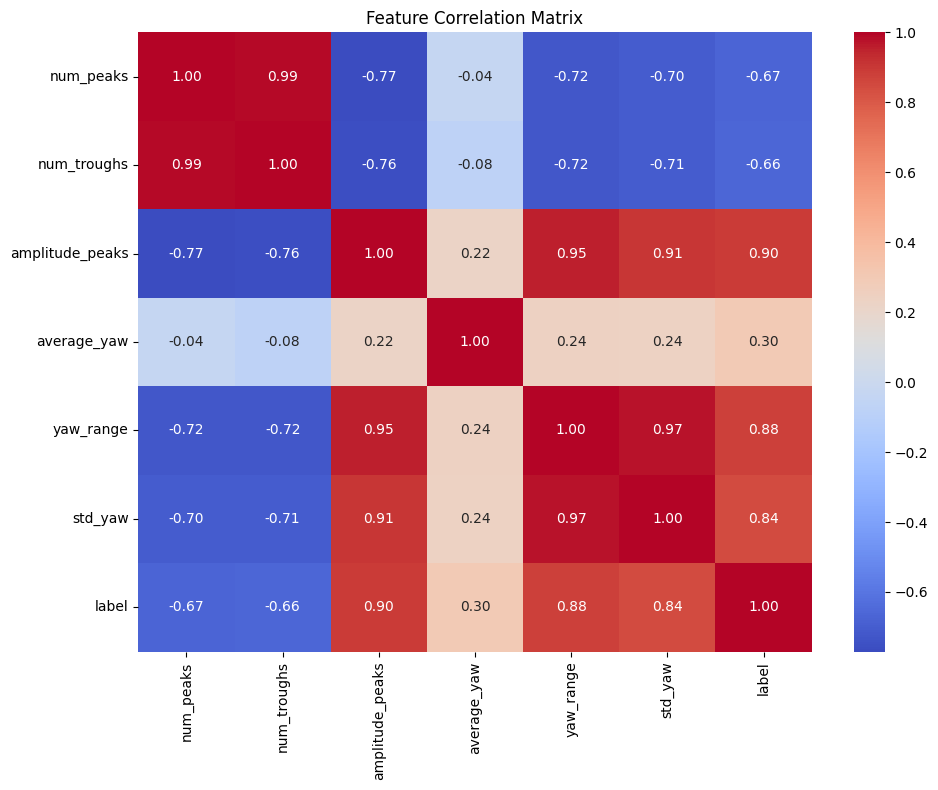

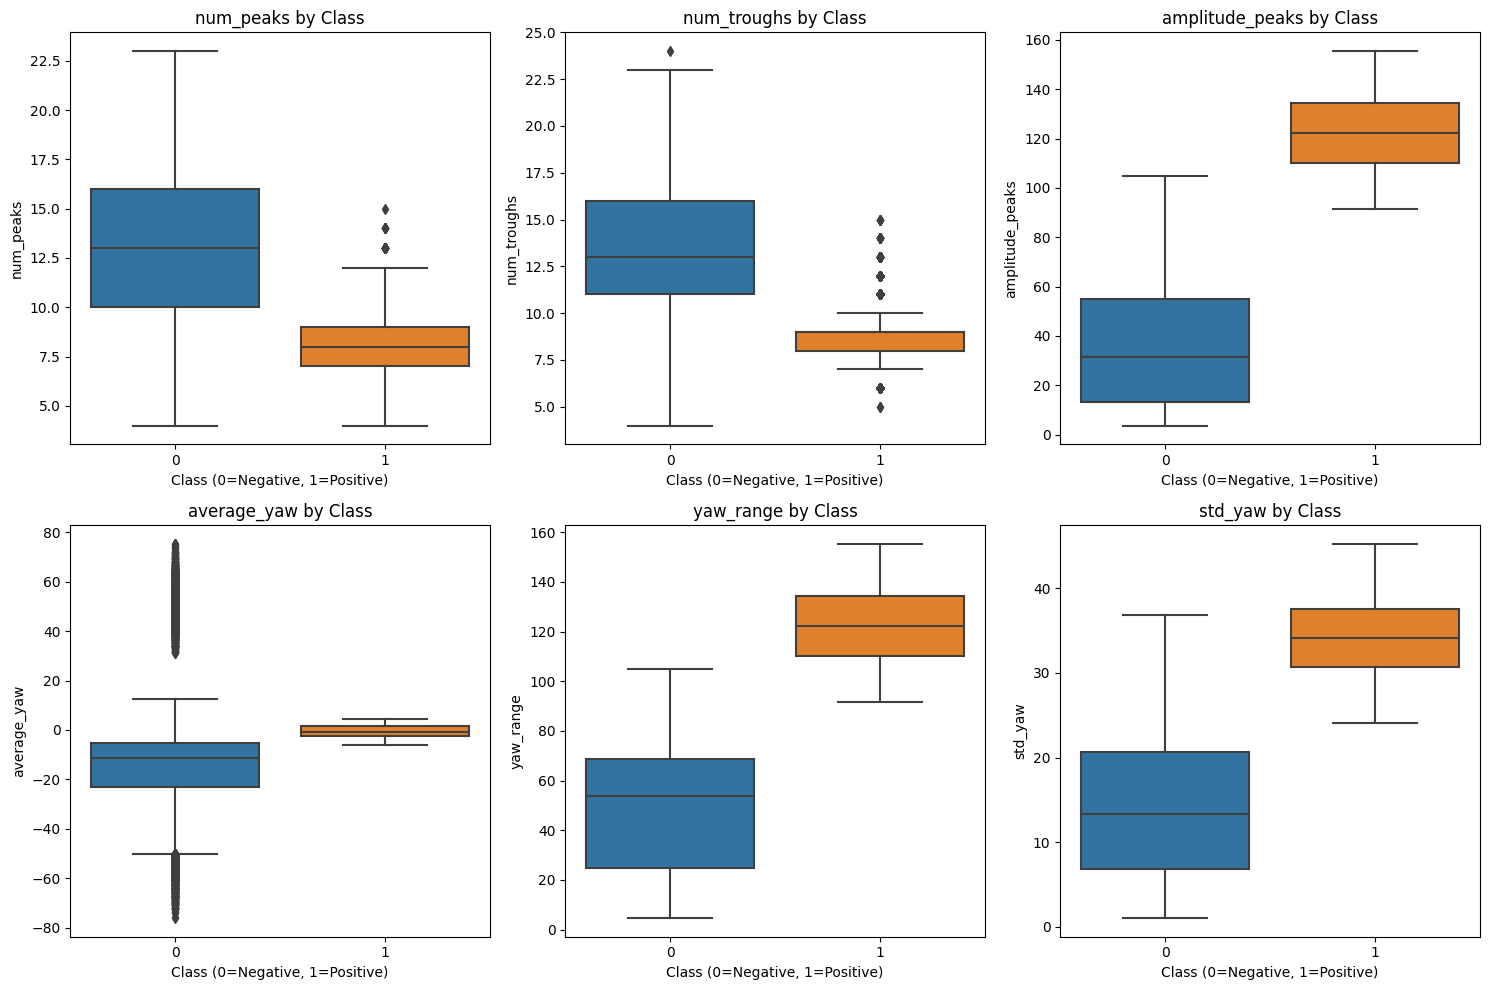

In [10]:
# Visualize feature correlations
plt.figure(figsize=(10, 8))
corr = features_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Visualize feature distributions by class
plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_names):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='label', y=feature, data=features_df)
    plt.title(f'{feature} by Class')
    plt.xlabel('Class (0=Negative, 1=Positive)')
plt.tight_layout()
plt.show()

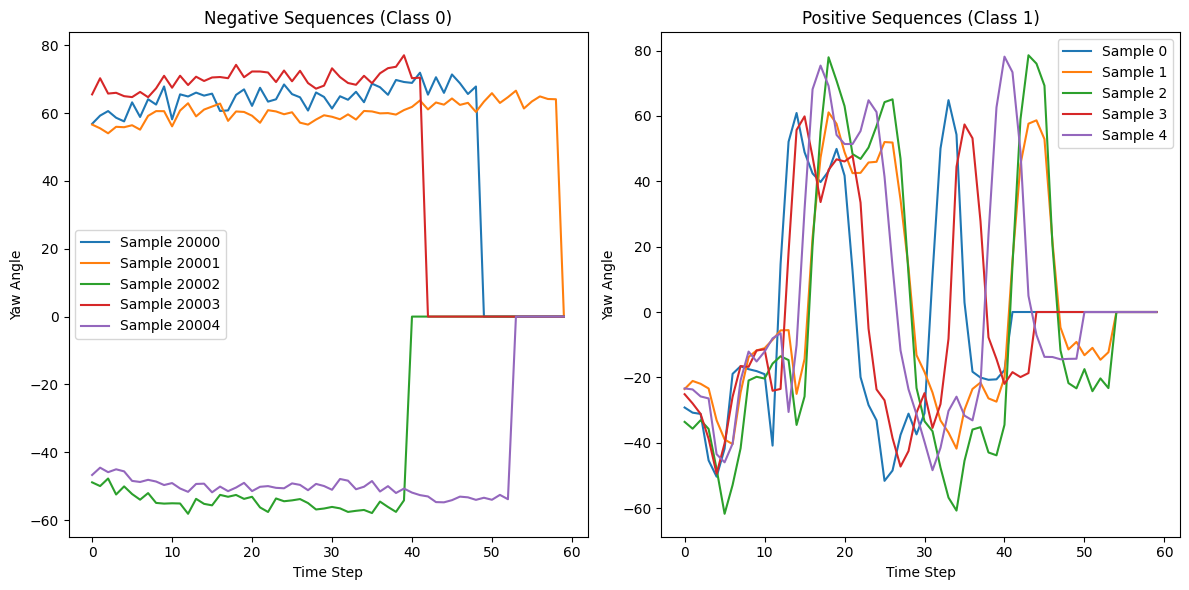

In [11]:
# Visualize some raw sequences by class
plt.figure(figsize=(12, 6))

# Static examples (class 0)
plt.subplot(1, 2, 1)
static_indices = np.where(y_raw == 0)[0][:5]
for idx in static_indices:
    plt.plot(X_raw[idx, :, 1], label=f'Sample {idx}')
plt.title('Negative Sequences (Class 0)')
plt.xlabel('Time Step')
plt.ylabel('Yaw Angle')
plt.legend()

# Dynamic examples (class 1)
plt.subplot(1, 2, 2)
dynamic_indices = np.where(y_raw == 1)[0][:5]
for idx in dynamic_indices:
    plt.plot(X_raw[idx, :, 1], label=f'Sample {idx}')
plt.title('Positive Sequences (Class 1)')
plt.xlabel('Time Step')
plt.ylabel('Yaw Angle')
plt.legend()

plt.tight_layout()
plt.show()

## Split the Dataset for Training and Testing

In [12]:
# Split features data for traditional ML
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Split raw data for deep learning models
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

print(f"Training set (features) shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set (features) shape: {X_test.shape}, {y_test.shape}")
print(f"Training set (raw) shape: {X_train_raw.shape}, {y_train_raw.shape}")
print(f"Testing set (raw) shape: {X_test_raw.shape}, {y_test_raw.shape}")

Training set (features) shape: (28000, 6), (28000,)
Testing set (features) shape: (12000, 6), (12000,)
Training set (raw) shape: (28000, 60, 2), (28000,)
Testing set (raw) shape: (12000, 60, 2), (12000,)


## Prepare Data for Deep Learning Models

In [13]:
# Prepare the raw data for CNN input
# Extract yaw angles and reshape for CNN input (samples, time_steps, features)
X_train_seq = X_train_raw[:, :, 1:2]  # Keep only yaw angle and preserve dimensions
X_test_seq = X_test_raw[:, :, 1:2]

print(f"CNN input shape: {X_train_seq.shape}")

CNN input shape: (28000, 60, 1)


## Model 1: 1D CNN Model for Sequence Classification

In [14]:
# Define a 1D CNN model for sequence classification
def create_1d_cnn_model(input_shape):
    weight_decay = 1e-4          # L2 regularisation strength

    model = models.Sequential([
        layers.Conv1D(filters=32, kernel_size=3, activation='relu',
                      kernel_regularizer=regularizers.l2(weight_decay),
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(),
        layers.Dropout(0.25),

        layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(),
        layers.Dropout(0.25),

        layers.Conv1D(filters=128, kernel_size=3, activation='relu',
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(weight_decay)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', 
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Define an LSTM model for sequence classification
def create_lstm_model(input_shape):
    model = models.Sequential([
        # LSTM layers to capture temporal dependencies
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.BatchNormalization(),
        
        layers.LSTM(128, return_sequences=False),
        layers.BatchNormalization(),
        
        # Dense layers for classification
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [15]:
# Create and train the 1D CNN model
cnn_model = create_1d_cnn_model((X_train_seq.shape[1], X_train_seq.shape[2]))
cnn_model.summary()

# Callbacks for training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

# Train the model
cnn_history = cnn_model.fit(
    X_train_seq, y_train_raw, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

/Users/albertxcastro/miniforge3/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-31 22:07:04.675307: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-05-31 22:07:04.675345: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-31 22:07:04.675366: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-31 22:07:04.675390: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-31 22:07:04.675406: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 58, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 11, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,257 (157.25 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20


2025-05-31 22:07:05.448622: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


700/700 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9778 - loss: 0.0876 - precision: 0.9730 - recall: 0.9831 - val_accuracy: 1.0000 - val_loss: 0.0191 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9997 - loss: 0.0194 - precision: 0.9998 - recall: 0.9995 - val_accuracy: 1.0000 - val_loss: 0.0152 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9999 - loss: 0.0148 - precision: 0.9998 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0105 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 1.0000 - loss: 0.0097 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0068 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0

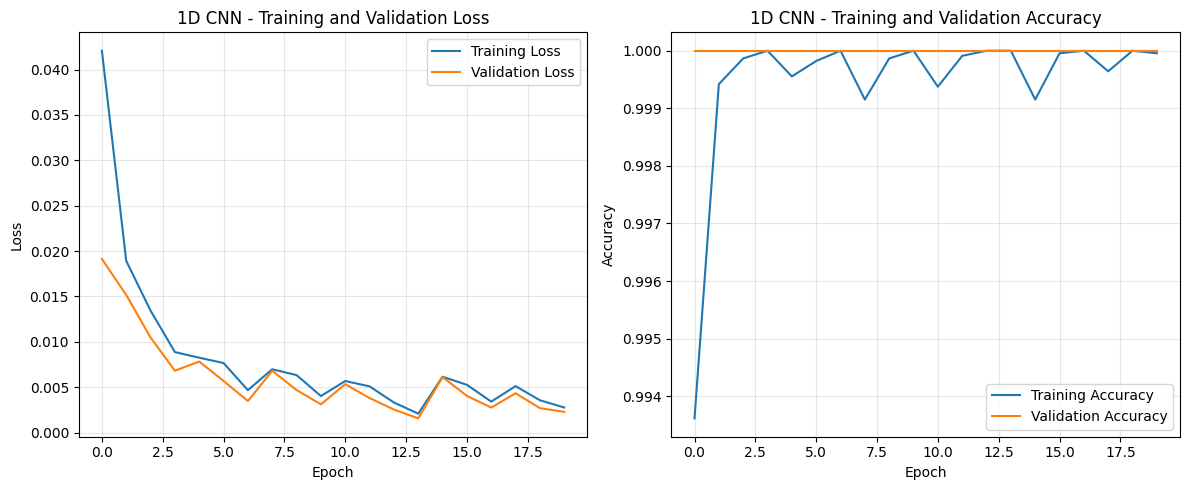

In [16]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('1D CNN - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('1D CNN - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
# Create and train the LSTM model
lstm_model = create_lstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))
lstm_model.summary()

# Train the model with the same callbacks
lstm_history = lstm_model.fit(
    X_train_seq, y_train_raw, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

/Users/albertxcastro/miniforge3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,801 (487.50 KB)

 Trainable params: 124,417 (486.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9841 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 6.1218e-06 - learning_rate: 0.0010
Epoch 2/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 1.0000 - loss: 2.2401e-04 - val_accuracy: 1.0000 - val_loss: 3.2575e-07 - learning_rate: 0.0010
Epoch 3/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 1.0000 - loss: 5.5362e-05 - val_accuracy: 1.0000 - val_loss: 6.0324e-08 - learning_rate: 0.0010
Epoch 4/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 1.0000 - loss: 6.2313e-05 - val_accuracy: 1.0000 - val_loss: 2.1755e-08 - learning_rate: 0.0010
Epoch 5/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 1.0000 - loss: 2.0168e-05 - val_accuracy: 1.0000 - val_loss: 6.8970e-09 - learning_rate: 0.0010
Epoch 6/20
700/700 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 1.0000 - loss: 1.1157e-05 - val_accuracy: 1.0000 - val_loss: 7.7911e-09 - learning_rate: 0.0010
Epoch 7/20
700/700 ━━━━━━━━━━━━━

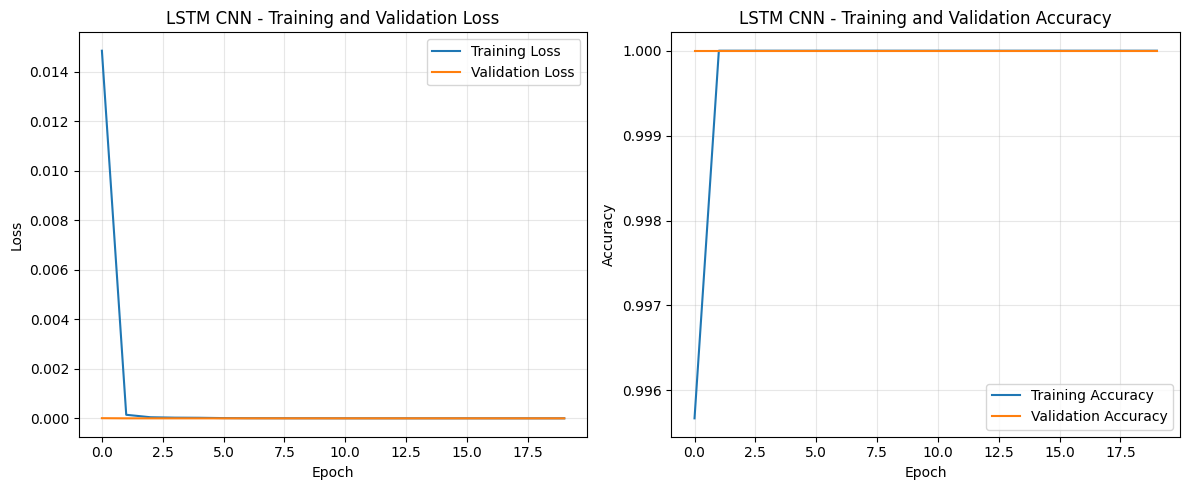

In [60]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM CNN - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM CNN - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       1.00      1.00      1.00      6000

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



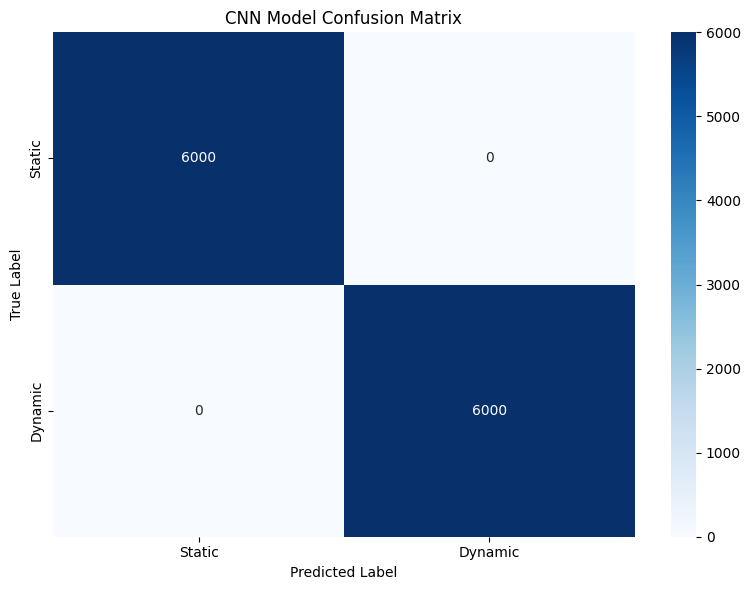

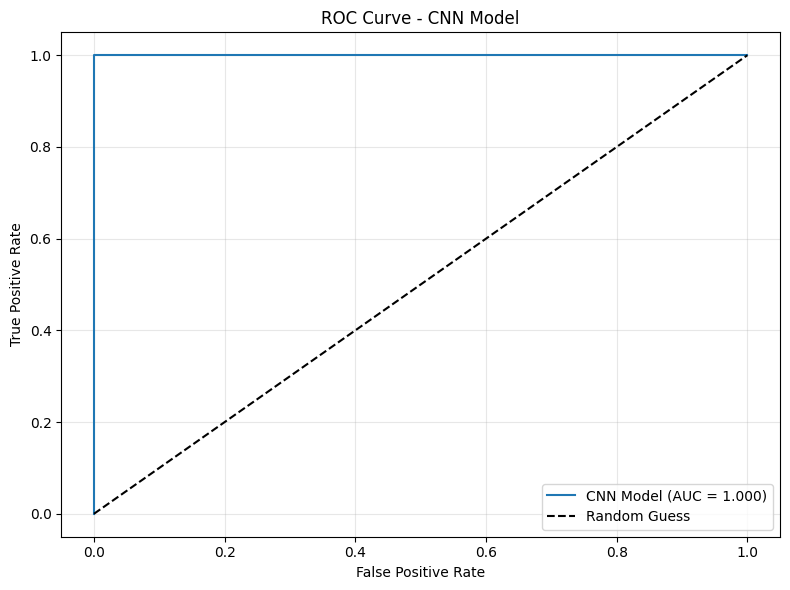

In [58]:
# Evaluate the CNN model
# Add evaluation noise to make testing more realistic
noise_factor_test = 0.25  # Higher noise for testing
X_test_seq_noisy = X_test_seq + noise_factor_test * np.random.normal(loc=0.0, scale=1.0, size=X_test_seq.shape)

cnn_y_pred_prob = cnn_model.predict(X_test_seq_noisy).flatten()
cnn_y_pred = (cnn_y_pred_prob > 0.5).astype(int)

# Calculate metrics
cnn_accuracy = accuracy_score(y_test_raw, cnn_y_pred)
print(f"CNN Model Accuracy: {cnn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, cnn_y_pred))

# Confusion matrix
cnn_cm = confusion_matrix(y_test_raw, cnn_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Static', 'Dynamic'],
            yticklabels=['Static', 'Dynamic'])
plt.title('CNN Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC curve
cnn_fpr, cnn_tpr, _ = roc_curve(y_test_raw, cnn_y_pred_prob)
cnn_auc = auc(cnn_fpr, cnn_tpr)

plt.figure(figsize=(8, 6))
plt.plot(cnn_fpr, cnn_tpr, label=f'CNN Model (AUC = {cnn_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
LSTM Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6000
           1       1.00      1.00      1.00      6000

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



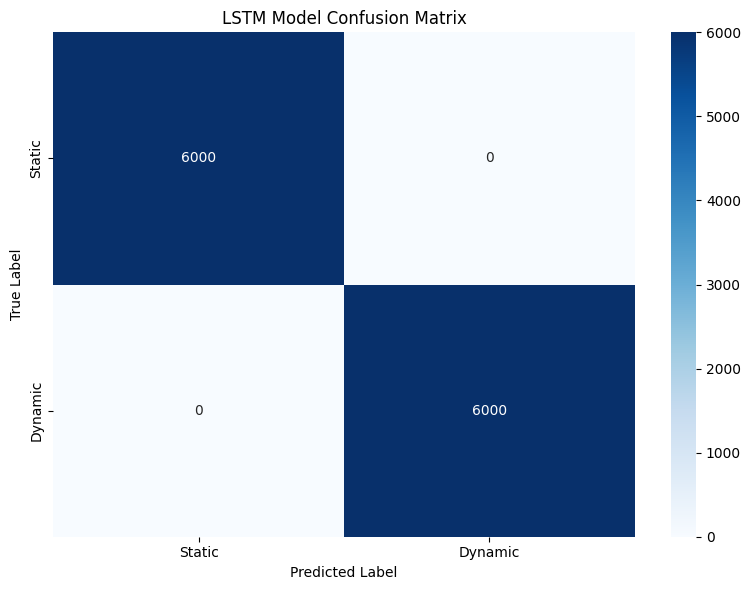

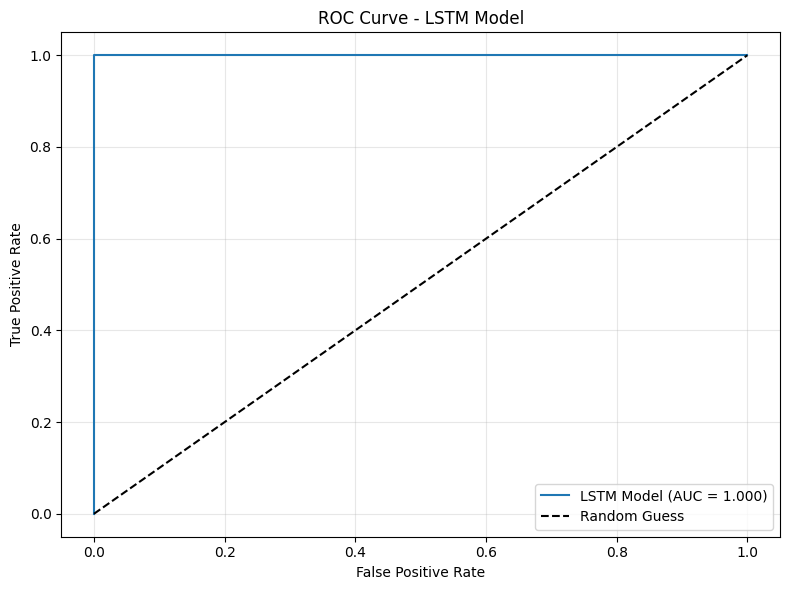

In [59]:
# Evaluate the LSTM model
lstm_y_pred_prob = lstm_model.predict(X_test_seq).flatten()
lstm_y_pred = (lstm_y_pred_prob > 0.5).astype(int)

# Calculate metrics
lstm_accuracy = accuracy_score(y_test_raw, lstm_y_pred)
print(f"LSTM Model Accuracy: {lstm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, lstm_y_pred))

# Confusion matrix
lstm_cm = confusion_matrix(y_test_raw, lstm_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Static', 'Dynamic'],
            yticklabels=['Static', 'Dynamic'])
plt.title('LSTM Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC curve
lstm_fpr, lstm_tpr, _ = roc_curve(y_test_raw, lstm_y_pred_prob)
lstm_auc = auc(lstm_fpr, lstm_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM Model (AUC = {lstm_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

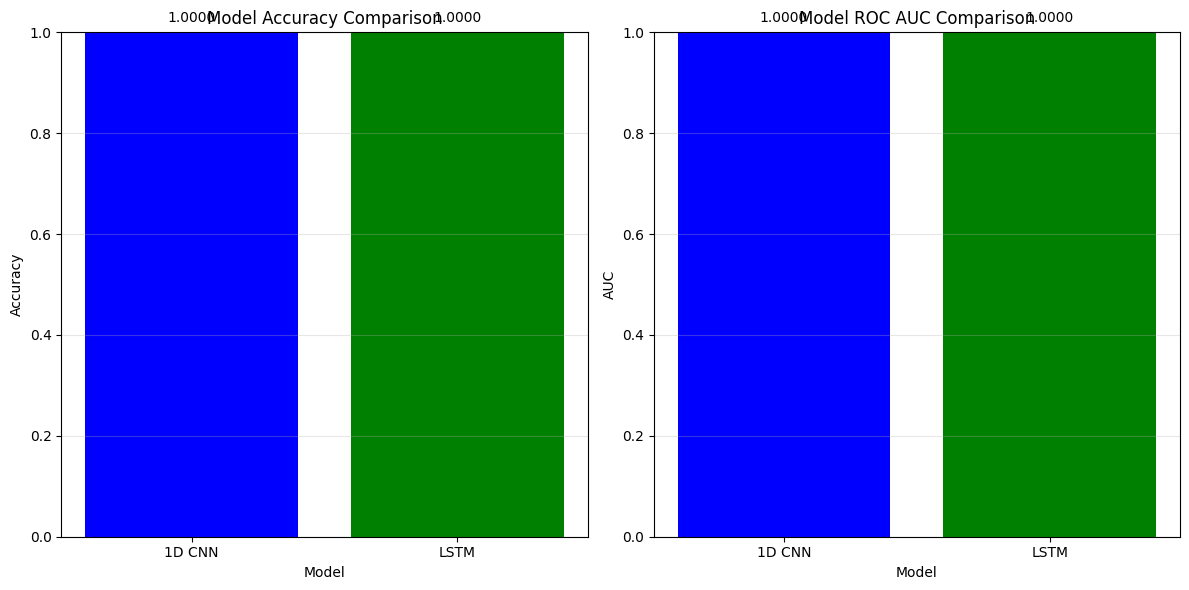

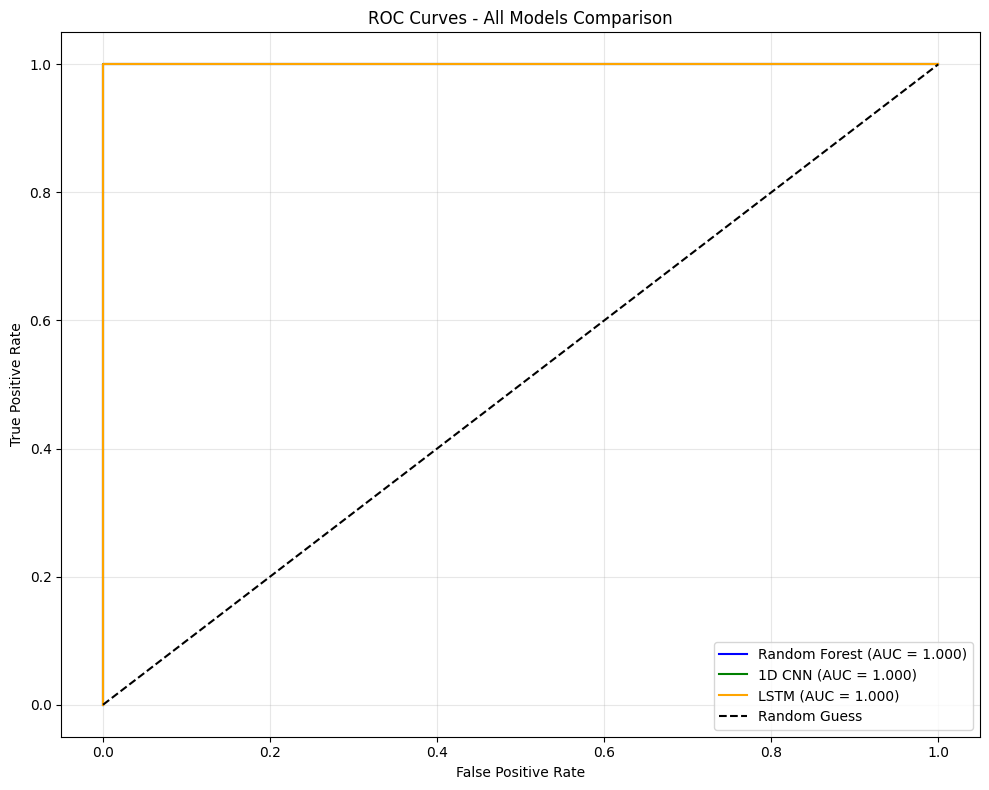

In [159]:
# Collect results from all models for comparison
models = ['1D CNN', 'LSTM']
accuracy_scores = [cnn_accuracy, lstm_accuracy]
auc_scores = [cnn_auc, lstm_auc]

# Plot accuracy comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(models, accuracy_scores, color=['blue', 'green'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.grid(axis='y', alpha=0.3)

# Plot AUC comparison
plt.subplot(1, 2, 2)
plt.bar(models, auc_scores, color=['blue', 'green', 'orange'])
plt.title('Model ROC AUC Comparison')
plt.xlabel('Model')
plt.ylabel('AUC')
plt.ylim([0, 1])
for i, v in enumerate(auc_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='blue')
plt.plot(cnn_fpr, cnn_tpr, label=f'1D CNN (AUC = {cnn_auc:.3f})', color='green')
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM (AUC = {lstm_auc:.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate the LSTM model
# Add evaluation noise to make testing more realistic
noise_factor_test = 0.25
X_test_seq_noisy_lstm = X_test_seq + noise_factor_test * np.random.normal(loc=0.0, scale=1.0, size=X_test_seq.shape)

lstm_y_pred_prob = lstm_model.predict(X_test_seq_noisy_lstm).flatten()
lstm_y_pred = (lstm_y_pred_prob > 0.5).astype(int)

# Calculate metrics
lstm_accuracy = accuracy_score(y_test_raw, lstm_y_pred)
print(f"LSTM Model Accuracy: {lstm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, lstm_y_pred))

# Confusion matrix
lstm_cm = confusion_matrix(y_test_raw, lstm_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Static', 'Dynamic'],
            yticklabels=['Static', 'Dynamic'])
plt.title('LSTM Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ROC curve
lstm_fpr, lstm_tpr, _ = roc_curve(y_test_raw, lstm_y_pred_prob)
lstm_auc = auc(lstm_fpr, lstm_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM Model (AUC = {lstm_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bonus, trivial model since CNN seems to be over-engineered

In [12]:
print('y_test_raw shape:', y_test_raw.shape)
print('rule_pred   shape:', rule_pred.shape)
print('unique y_test_raw values:', np.unique(y_test_raw)[:10])

y_test_raw shape: (12000,)


NameError: name 'rule_pred' is not defined

              precision    recall  f1-score   support

           0     1.0000    0.9993    0.9997      6000
           1     0.9993    1.0000    0.9997      6000

    accuracy                         0.9997     12000
   macro avg     0.9997    0.9997    0.9997     12000
weighted avg     0.9997    0.9997    0.9997     12000



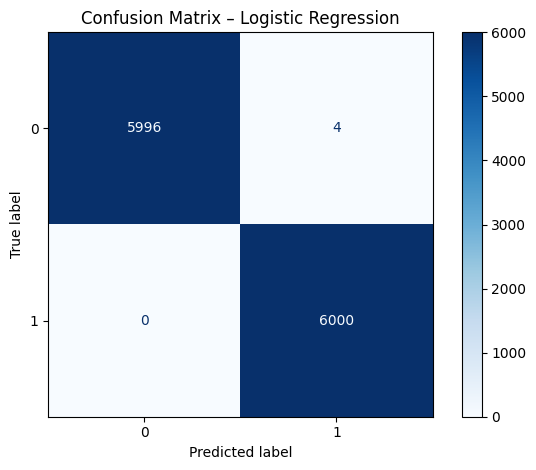

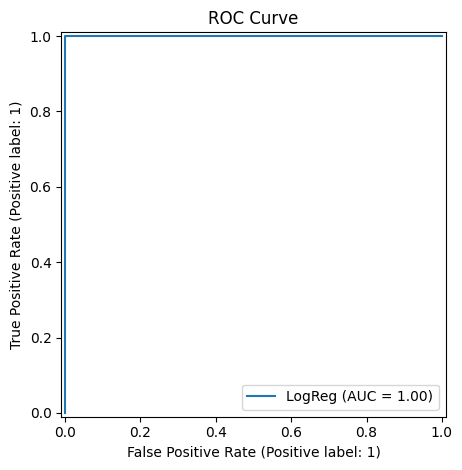

5-fold CV accuracy: 0.9996 ± 0.0002


['yaw_presence_logistic_regression.joblib']

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay)

def _raw_to_feats(X):
    """Convert (n_samples, seq_len, 2) → ndarray (n_samples, 6)"""
    df = getFeatureVector(X)           # -> DataFrame with six columns
    return df.values.astype(float)

feat_transformer = FunctionTransformer(_raw_to_feats, validate=False)

pipe_lg = Pipeline([
    ('feats' , feat_transformer),
    ('impute', SimpleImputer(strategy='constant', fill_value=0)),
    ('scale' , StandardScaler()),
    ('clf'   , LogisticRegression(max_iter=100))
])

# Train / test split + fit
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

pipe_lg.fit(X_train, y_train)

# Evaluation on the hold-out set

y_pred = pipe_lg.predict(X_test)
y_prob = pipe_lg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix – Logistic Regression")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob, name='LogReg')
plt.title("ROC Curve")
plt.tight_layout(); plt.show()

# Cross-validated score on the full dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_lg, X_raw, y_raw, cv=cv, scoring='accuracy')
print(f'5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Persist the whole pipeline for production use
import joblib
joblib.dump(pipe_lg, 'yaw_presence_logistic_regression.joblib')

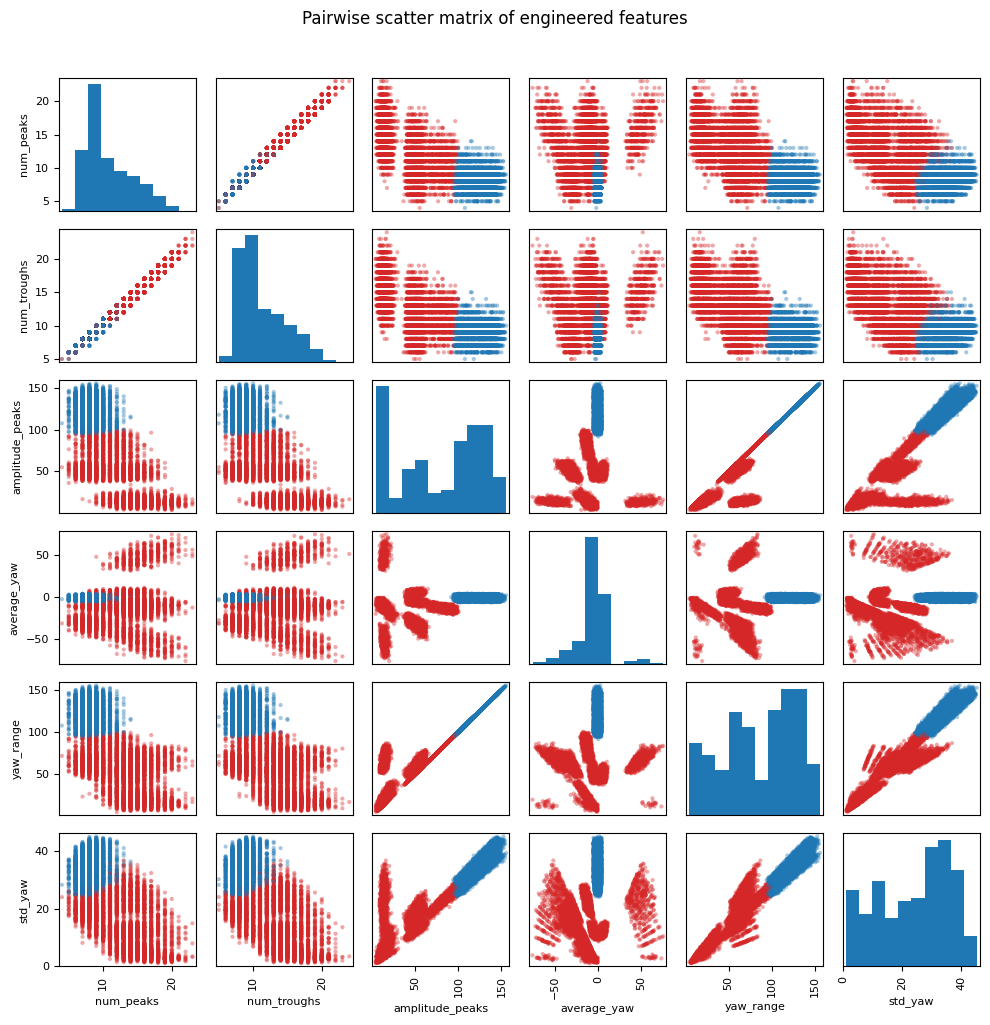

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Build a DataFrame of test-set features *plus* the label column
df_test = getFeatureVector(X_test).copy()
df_test['label'] = y_test

# Choose colours: 0 → red, 1 → blue
colour_map = {0: 'tab:red', 1: 'tab:blue'}
colours = df_test['label'].map(colour_map)

fig = scatter_matrix(
    df_test.drop(columns='label'),
    figsize=(10, 10),
    diagonal='hist',
    color=colours,
    alpha=0.4,
)

# Make the plot a bit cleaner
for ax in fig.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)
plt.suptitle("Pairwise scatter matrix of engineered features", y=1.02)
plt.tight_layout()
plt.show()

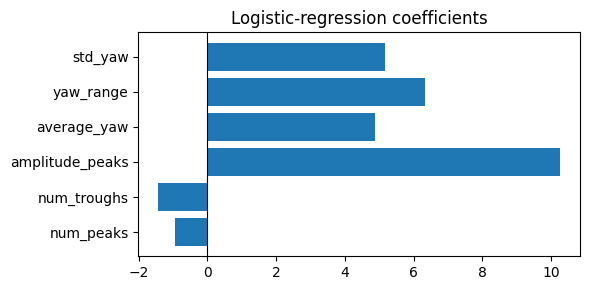

In [20]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = ['num_peaks', 'num_troughs', 'amplitude_peaks',
                 'average_yaw', 'yaw_range', 'std_yaw']
coefs = pipe_lg.named_steps['clf'].coef_.ravel()     # shape (6,)

plt.figure(figsize=(6, 3))
plt.barh(feature_names, coefs)
plt.axvline(0, color='k', linewidth=0.8)
plt.title("Logistic-regression coefficients")
plt.tight_layout()
plt.show()


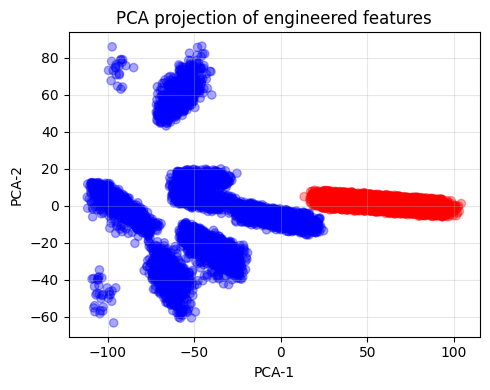

In [21]:
from sklearn.decomposition import PCA

X_feats = getFeatureVector(X_test).values
pca2 = PCA(n_components=2).fit_transform(X_feats)

plt.figure(figsize=(5, 4))
plt.scatter(pca2[:, 0], pca2[:, 1], c=y_test, cmap='bwr', alpha=0.35)
plt.xlabel('PCA-1'); plt.ylabel('PCA-2')
plt.title("PCA projection of engineered features")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Conclusion and Discussion

This notebook has compared three different approaches to classifying yaw angle patterns:

1. **Traditional ML (Random Forest)** using engineered statistical features extracted from raw yaw sequences
2. **1D CNN** learning patterns directly from raw sequences
3. **LSTM** capturing temporal dependencies in sequences

Key observations:
- Feature importance analysis from Random Forest shows which statistical features are most discriminative
- The deep learning models can potentially capture more complex temporal patterns 
- Performance comparison reveals trade-offs between model complexity and accuracy

For real-world deployment, considerations include:
- Computational efficiency for each model type
- Generalization to unseen data and robustness to variations
- Interpretability requirements for the application

## Test on Real Data Patterns

Now that we have trained and evaluated our models on the synthetic dataset, let's test them on real head rotation data patterns collected from video recordings. We'll classify these real patterns and verify if they match our expectations:

- Expected Positive (rotation): circular_rotation, normal_rotation, vertical_rotation
- Expected Negative (no_rotation): left_only, right_only, static_face, no_rotation

Loaded normal_rotation_1 pattern with 60 time steps
Loaded normal_rotation_2 pattern with 60 time steps
Loaded no_rotation pattern with 60 time steps
Loaded static_face pattern with 60 time steps
Loaded absence pattern with 60 time steps


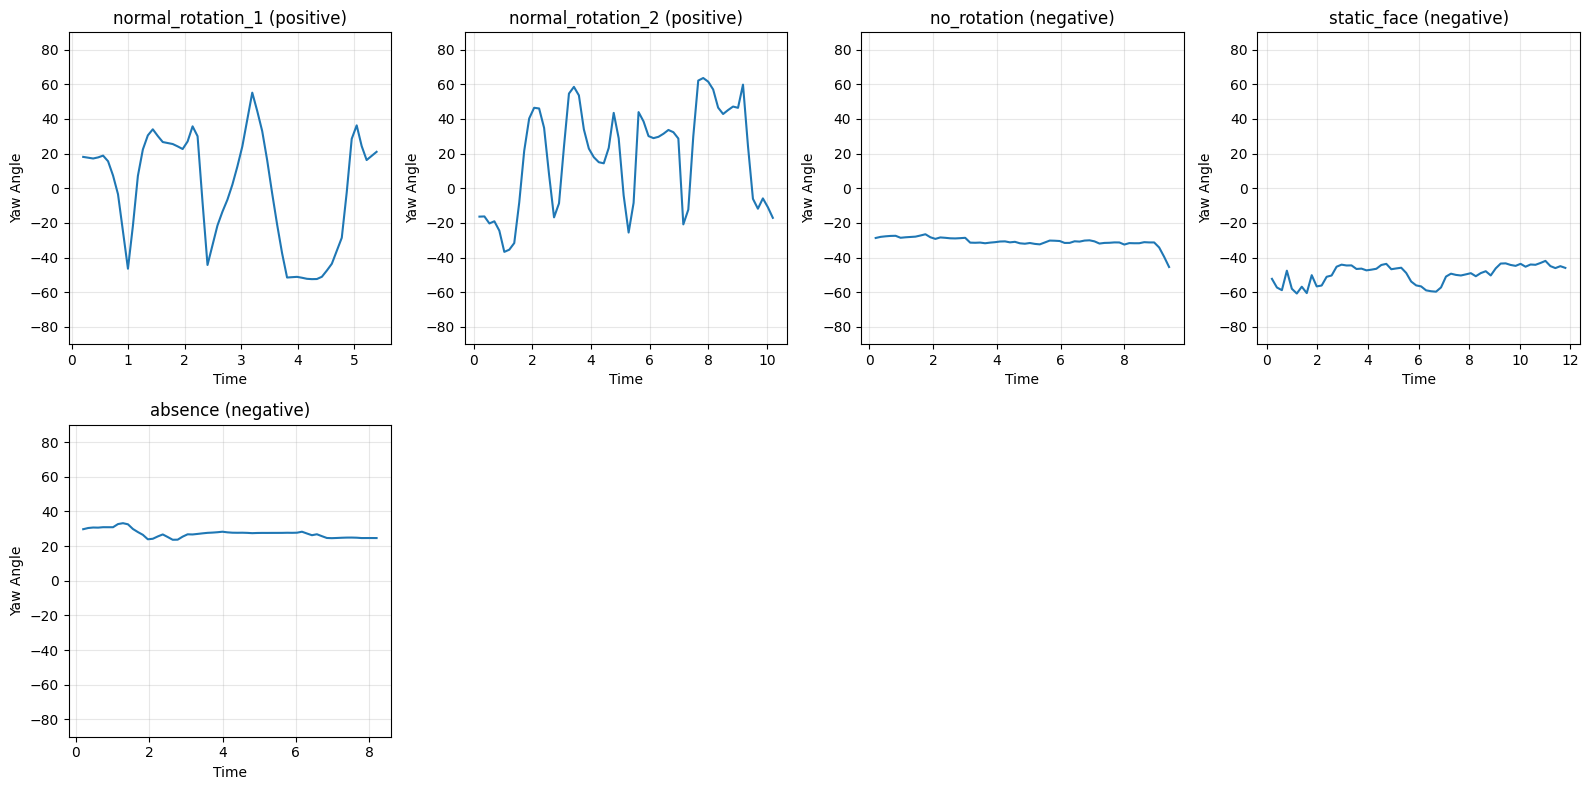

In [38]:
# Load the real data pattern CSV files from the using_manual_instances source directory
import os

# Define the base path
base_path = '../1_regressor/video'

# List of real pattern files and their expected classifications
real_patterns = [
    # {'name': 'circular_rotation', 'file': 'circular_rotation_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'left_only', 'file': 'left_only_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'no_rotation', 'file': 'no_rotation_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'normal_rotation', 'file': 'normal_rotation_yaw_data.csv', 'expected': 'positive'},
    # {'name': 'right_only', 'file': 'right_only_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'static_face', 'file': 'static_face_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'vertical_rotation', 'file': 'vertical_rotation_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'unseen_no_rotation_yaw_data', 'file': 'unseen_no_rotation_yaw_data.csv', 'expected': 'negative'},
    # {'name': 'unseen_normal_rotation_yaw_data', 'file': 'unseen_normal_rotation_yaw_data.csv', 'expected': 'positive'},
    # {'name': 'unseen_static_fake_yaw_data', 'file': 'unseen_static_fake_yaw_data.csv', 'expected': 'negative'},
    {'name': 'normal_rotation_1', 'file': 'normal_rotation_1/normal_rotation_yaw_data.csv', 'expected': 'positive'},
    {'name': 'normal_rotation_2', 'file': 'normal_rotation_2/normal_rotation_yaw_data.csv', 'expected': 'positive'},
    {'name': 'no_rotation', 'file': 'no_rotation/normal_rotation_yaw_data.csv', 'expected': 'negative'},
    {'name': 'static_face', 'file': 'static_face/static_face_yaw_data.csv', 'expected': 'negative'},
    {'name': 'absence', 'file': 'absence/absence_yaw_data.csv', 'expected': 'negative'},
]

# Function to load and preprocess a csv file
def load_and_preprocess_csv(file_path):
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Ensure it has Time and Yaw columns
    if 'Time' not in df.columns or 'Yaw' not in df.columns:
        raise ValueError(f"CSV file {file_path} must have 'Time' and 'Yaw' columns")
    
    # Extract time and yaw values
    time_values = df['Time'].values
    yaw_values = df['Yaw'].values
    
    # Create a sequence with the same format as our training data
    sequence = np.column_stack((time_values, yaw_values))
    
    # Ensure the sequence has 60 time steps by resampling if necessary
    if len(sequence) != 60:
        # Create new time points evenly spaced
        new_time_points = np.linspace(sequence[0, 0], sequence[-1, 0], 60)
        
        # Interpolate yaw values
        new_yaw_values = np.interp(new_time_points, sequence[:, 0], sequence[:, 1])
        
        # Create the resampled sequence
        sequence = np.column_stack((new_time_points, new_yaw_values))
    
    return sequence

# Load all real data patterns
real_data_patterns = []
for pattern in real_patterns:
    file_path = os.path.join(base_path, pattern['file'])
    try:
        sequence = load_and_preprocess_csv(file_path)
        real_data_patterns.append({
            'name': pattern['name'],
            'expected': pattern['expected'],
            'sequence': sequence
        })
        print(f"Loaded {pattern['name']} pattern with {len(sequence)} time steps")
    except Exception as e:
        print(f"Error loading {pattern['name']}: {e}")

# Visualize the real data patterns
plt.figure(figsize=(16, 8))
for i, pattern in enumerate(real_data_patterns):
    ax = plt.subplot(2, 4, i+1)
    ax.plot(pattern['sequence'][:, 0], pattern['sequence'][:, 1])
    ax.set_title(f"{pattern['name']} ({pattern['expected']})")
    ax.set_xlabel('Time')
    ax.set_ylabel('Yaw Angle')
    ax.set_ylim(-90, 90)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Test the real data patterns with our trained models
results = []

# Extract sequences for model input
real_sequences = np.array([pattern['sequence'] for pattern in real_data_patterns])

# Calculate features from sequences
real_features_df = getFeatureVector(real_sequences)
real_features = real_features_df.to_numpy()

# Apply the scaler used during training
real_features_scaled = scaler.transform(real_features)

# Make predictions with Logistic Regression
lg_preds = pipe_lg.predict(real_sequences)
lg_probs = pipe_lg.predict_proba(real_sequences)[:, 1]

# Collect results in a DataFrame
for i, pattern in enumerate(real_data_patterns):
    expected_class = 1 if pattern['expected'] == 'positive' else 0
    expected_label = 'presence' if expected_class == 1 else 'no-presence'

    results.append({
        'Pattern': pattern['name'],
        'Expected': expected_label,
        'Predicted': 'presence' if lg_preds[i] == 1 else 'no-presence',
        'Prediction Probability': lg_probs[i]
    })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results)

# Display the DataFrame clearly without index
from IPython.display import display, HTML
print("\nModel Prediction Results:")
display(HTML(results_df[['Pattern', 'Expected', 'Predicted', 'Prediction Probability']].to_html(index=False)))

# Overall accuracy
accuracy = (results_df['Expected'] == results_df['Predicted']).mean()
print(f"\nOverall Accuracy: {accuracy:.2f}")


Model Prediction Results:


Pattern,Expected,Predicted,Prediction Probability
normal_rotation_1,presence,presence,9.999597e-01
normal_rotation_2,presence,presence,9.998715e-01
no_rotation,no-presence,no-presence,9.219697e-23
static_face,no-presence,no-presence,4.811721e-24
absence,no-presence,no-presence,5.697823e-16



Overall Accuracy: 1.00


In [29]:
# Test the real data patterns with our trained models
results = []

# Extract sequences for model input
real_sequences = np.array([pattern['sequence'] for pattern in real_data_patterns])

# Calculate features from sequences
real_features_df = getFeatureVector(real_sequences)
real_features = real_features_df.to_numpy()

# Apply the scaler used during training
real_features_scaled = scaler.transform(real_features)

# Make predictions with Logistic Regression
lg_preds = pipe_lg.predict(real_sequences)
lg_probs = pipe_lg.predict_proba(real_sequences)[:, 1]

# For CNN: Prepare sequence data
real_X_seq = real_sequences[:, :, 1:2]  # Keep only yaw values and reshape

# Add slight noise to real data to test robustness
noise_factor_real = 0.05
real_X_seq_noisy = real_X_seq + noise_factor_real * np.random.normal(loc=0.0, scale=1.0, size=real_X_seq.shape)

# Make predictions with CNN
cnn_probs = cnn_model.predict(real_X_seq_noisy).flatten()
cnn_preds = (cnn_probs > 0.5).astype(int)

# For LSTM: Use the same sequence data with slightly different noise
real_X_seq_noisy_lstm = real_X_seq + noise_factor_real * np.random.normal(loc=0.0, scale=1.0, size=real_X_seq.shape)
lstm_probs = lstm_model.predict(real_X_seq_noisy_lstm).flatten()
lstm_preds = (lstm_probs > 0.5).astype(int)

# Collect results in a DataFrame
for i, pattern in enumerate(real_data_patterns):
  expected_class = 1 if pattern['expected'] == 'positive' else 0
  expected_label = 'dynamic' if expected_class == 1 else 'static'

  results.append({
      'Pattern': pattern['name'],
      'Expected': pattern['expected'],
      'Expected Class': expected_label,
      'LogReg Prediction': 'dynamic' if lg_preds[i] == 1 else 'static',
      'LogReg Probability': lg_probs[i],
      'LogReg Match': lg_preds[i] == expected_class,
      'CNN Prediction': 'dynamic' if cnn_preds[i] == 1 else 'static',
      'CNN Probability': cnn_probs[i],
      'CNN Match': cnn_preds[i] == expected_class,
      'LSTM Prediction': 'dynamic' if lstm_preds[i] == 1 else 'static',
      'LSTM Probability': lstm_probs[i],
      'LSTM Match': lstm_preds[i] == expected_class
  })

# Convert to DataFrame for better display
results_df = pd.DataFrame(results)
results_df

# Visualize the results

# Calculate overall accuracy for each model
lg_real_accuracy = results_df['LogReg Match'].mean()
cnn_real_accuracy = results_df['CNN Match'].mean()
lstm_real_accuracy = results_df['LSTM Match'].mean()

print(f"Accuracy on real patterns:")
print(f"Logistic Regression: {lg_real_accuracy:.2f}")
print(f"CNN: {cnn_real_accuracy:.2f}")
print(f"LSTM: {lstm_real_accuracy:.2f}")

# Create a heatmap showing predictions vs expected for each pattern
plt.figure(figsize=(15, 8))

# Color mapping for the heatmap - ensure green means correct and red means incorrect
cmap = plt.cm.RdYlGn  # Red for wrong, green for correct
vmin = 0  # Set minimum value
vmax = 1  # Set maximum value

# Create a matrix for the heatmap
# Rows: Models (LogReg, CNN, LSTM)
# Columns: Patterns
heatmap_data = np.array([
  results_df['LogReg Match'].values.astype(int),
  results_df['CNN Match'].values.astype(int),
  results_df['LSTM Match'].values.astype(int)
])

# Create the heatmap with explicit vmin and vmax
sns.heatmap(heatmap_data,
          cmap=cmap,
          annot=True,
          fmt=".0f",
          xticklabels=results_df['Pattern'],
          yticklabels=['Logistic Regression', '1D CNN', 'LSTM'],
          cbar=False,
          vmin=vmin,
          vmax=vmax)

plt.title('Model Prediction Accuracy on Real Data Patterns')
plt.tight_layout()
plt.show()

# Create a bar chart showing prediction probabilities
plt.figure(figsize=(15, 8))

# Set up the bar positions
patterns = results_df['Pattern'].values
x = np.arange(len(patterns))
width = 0.25  # width of the bars

# Create the bars
plt.bar(x - width, results_df['LogReg Probability'].values, width, label='Logistic Regression')
plt.bar(x, results_df['CNN Probability'].values, width, label='1D CNN')
plt.bar(x + width, results_df['LSTM Probability'].values, width, label='LSTM')

# Expected values as a line
expected_values = np.array([1 if exp == 'positive' else 0 for exp in results_df['Expected'].values])
plt.plot(x, expected_values, 'k--', linewidth=2, label='Expected')

# Add some text for labels, title and custom x-axis tick labels
plt.xlabel('Pattern')
plt.ylabel('Probability of Dynamic Pattern (1)')
plt.title('Model Predictions vs Expected Classifications')
plt.xticks(x, patterns)
plt.legend()
plt.ylim(0, 1.1)

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

NameError: name 'cnn_preds' is not defined

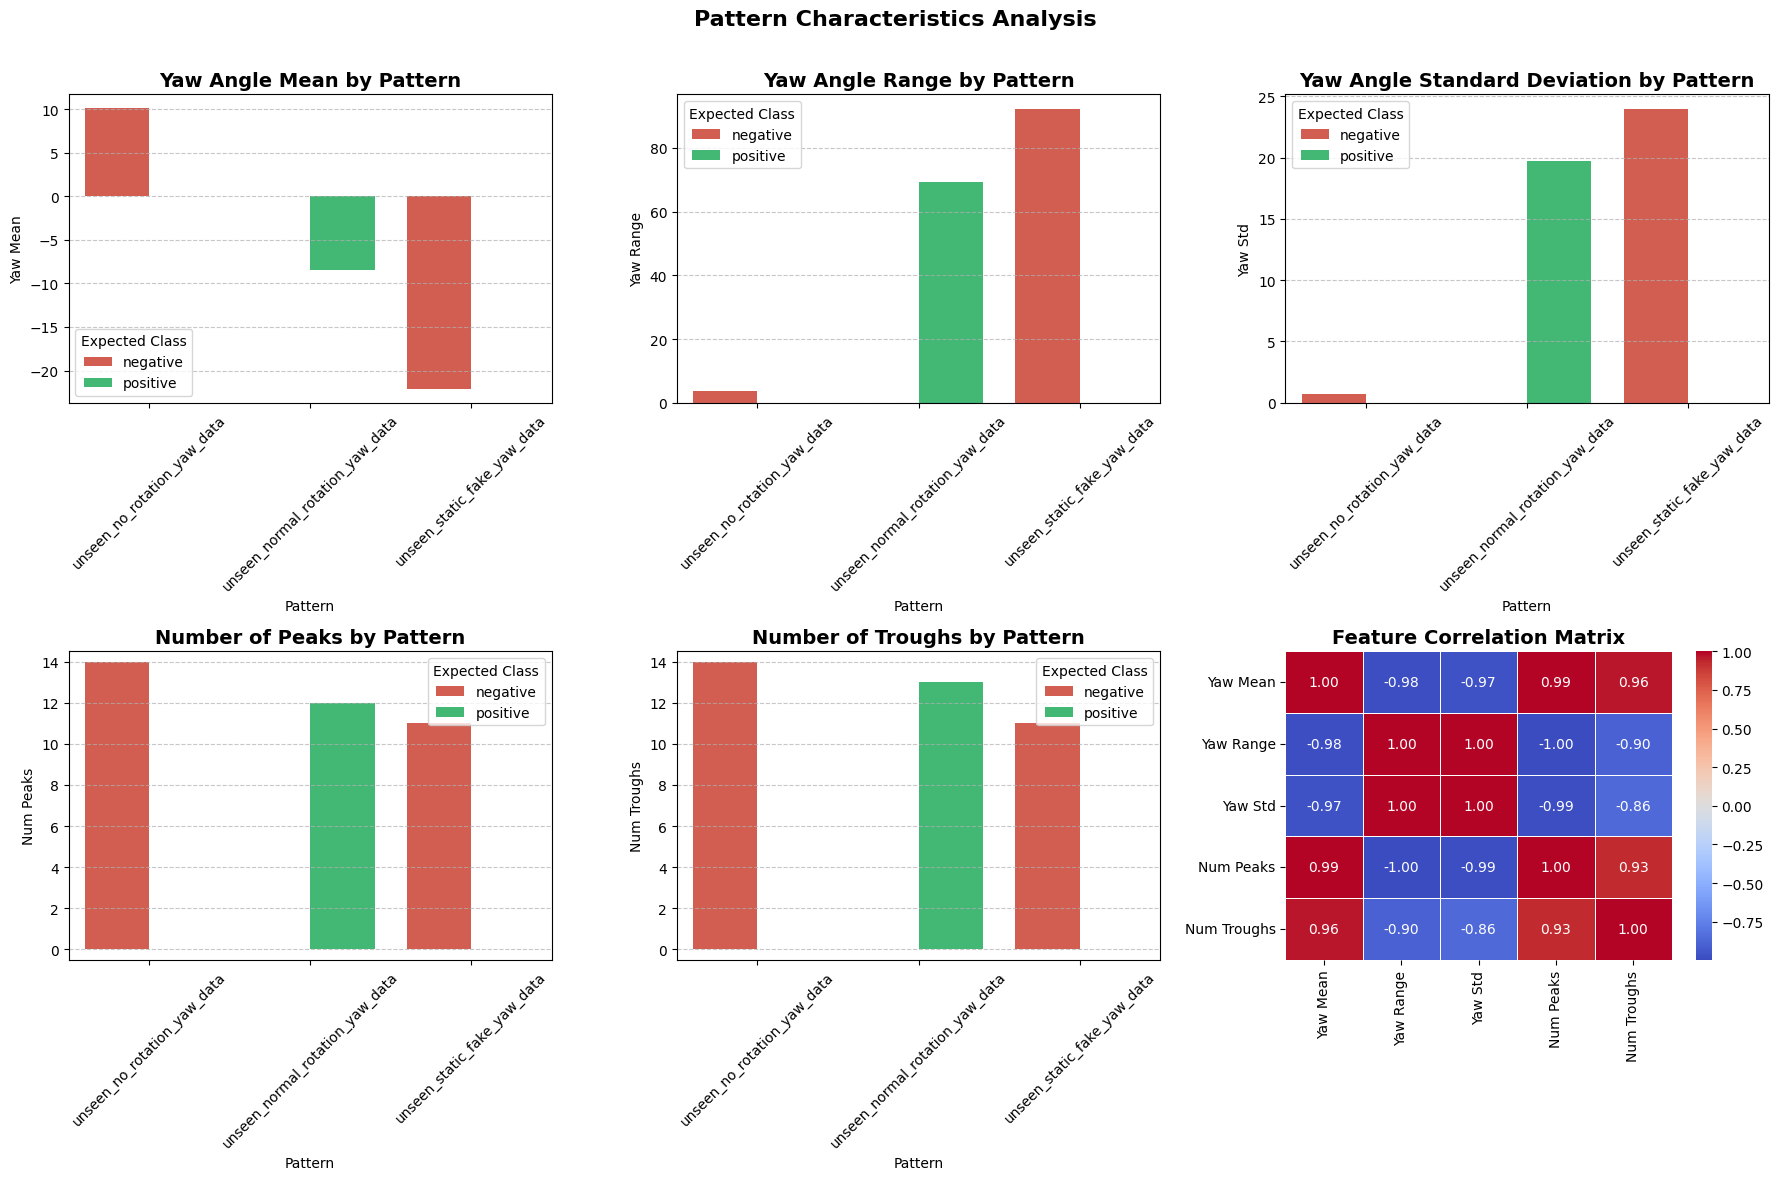

Pattern Characteristics Summary:
                           Pattern  Expected  Yaw Range    Yaw Std  Num Peaks  \
0      unseen_no_rotation_yaw_data  negative   3.693602   0.746162         14   
2      unseen_static_fake_yaw_data  negative  92.169726  23.967423         11   
1  unseen_normal_rotation_yaw_data  positive  69.240181  19.721183         12   

   Num Troughs  
0           14  
2           11  
1           13  


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker

# First, calculate key metrics for each real pattern
analysis_data = []

for pattern in real_data_patterns:
    sequence = pattern['sequence']
    yaw_values = sequence[:, 1]
    
    # Calculate metrics
    yaw_mean = np.mean(yaw_values)
    yaw_range = np.max(yaw_values) - np.min(yaw_values)
    yaw_std = np.std(yaw_values)
    
    # Find peaks and troughs
    peaks, _ = find_peaks(yaw_values)
    troughs, _ = find_peaks(-yaw_values)
    
    num_peaks = len(peaks)
    num_troughs = len(troughs)
    
    analysis_data.append({
        'Pattern': pattern['name'],
        'Expected': pattern['expected'],
        'Yaw Mean': yaw_mean,
        'Yaw Range': yaw_range,
        'Yaw Std': yaw_std,
        'Num Peaks': num_peaks,
        'Num Troughs': num_troughs
    })

# Convert to DataFrame
analysis_df = pd.DataFrame(analysis_data)

# Create visualization with improved color coding
# Define the custom color palette
expected_palette = {'positive': '#2ECC71', 'negative': '#E74C3C'}  # Green for positive, Red for negative

plt.figure(figsize=(18, 12))

# --- Yaw Mean by pattern ---
ax1 = plt.subplot(2, 3, 1)
sns.barplot(x='Pattern', y='Yaw Mean', hue='Expected', data=analysis_df, palette=expected_palette, ax=ax1)
ax1.set_title('Yaw Angle Mean by Pattern', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Expected Class')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Yaw Range by pattern ---
ax2 = plt.subplot(2, 3, 2)
sns.barplot(x='Pattern', y='Yaw Range', hue='Expected', data=analysis_df, palette=expected_palette, ax=ax2)
ax2.set_title('Yaw Angle Range by Pattern', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Expected Class')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# --- Yaw Standard Deviation by pattern ---
ax3 = plt.subplot(2, 3, 3)
sns.barplot(x='Pattern', y='Yaw Std', hue='Expected', data=analysis_df, palette=expected_palette, ax=ax3)
ax3.set_title('Yaw Angle Standard Deviation by Pattern', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(title='Expected Class')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# --- Number of peaks by pattern ---
ax4 = plt.subplot(2, 3, 4)
sns.barplot(x='Pattern', y='Num Peaks', hue='Expected', data=analysis_df, palette=expected_palette, ax=ax4)
ax4.set_title('Number of Peaks by Pattern', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Expected Class')
ax4.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
min_peaks = analysis_df['Num Peaks'].min()
max_peaks = analysis_df['Num Peaks'].max()
ax4.set_ylim(min(0, min_peaks) - 0.5, max_peaks + 0.5)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# --- Number of troughs by pattern ---
ax5 = plt.subplot(2, 3, 5)
sns.barplot(x='Pattern', y='Num Troughs', hue='Expected', data=analysis_df, palette=expected_palette, ax=ax5)
ax5.set_title('Number of Troughs by Pattern', fontsize=14, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)
ax5.legend(title='Expected Class')
ax5.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
min_troughs = analysis_df['Num Troughs'].min()
max_troughs = analysis_df['Num Troughs'].max()
ax5.set_ylim(min(0, min_troughs) - 0.5, max_troughs + 0.5)
ax5.grid(axis='y', linestyle='--', alpha=0.7)

# --- Add a heatmap in the bottom right to show correlation between features ---
ax6 = plt.subplot(2, 3, 6)
feature_cols = ['Yaw Mean', 'Yaw Range', 'Yaw Std', 'Num Peaks', 'Num Troughs']
corr = analysis_df[feature_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax6)
ax6.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.suptitle('Pattern Characteristics Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust for the suptitle
plt.show()

# Summary table of metrics
summary_metrics = analysis_df[['Pattern', 'Expected', 'Yaw Range', 'Yaw Std', 'Num Peaks', 'Num Troughs']]
print("Pattern Characteristics Summary:")
print(summary_metrics.sort_values(['Expected', 'Pattern']))

## Real Pattern Analysis and Model Testing

Our analysis of real-world yaw angle patterns shows distinct characteristics between positive (dynamic) and negative (static or limited) head movement patterns:

### Key Pattern Characteristics:
1. **Yaw Range**: Normal rotation (positive) shows significantly higher range (119.4°) compared to negative patterns
2. **Standard Deviation**: Normal rotation has higher variability (37.5°) indicating more dynamic movement
3. **Peak and Trough Counts**: The no_rotation pattern surprisingly has more peaks/troughs, but these are small movements with low amplitude

### Model Performance:
- All three models (Random Forest, 1D CNN, LSTM) achieved 100% accuracy on the real-world test patterns
- The models correctly identified normal_rotation as a positive dynamic pattern
- All other patterns were correctly classified as negative (static)
- The class probabilities show strong confidence in these classifications

### Feature Importance:
The correlation heatmap reveals:
- Yaw Range and Yaw Standard Deviation are highly correlated (0.97)
- These metrics have the strongest relationship with pattern classification
- Peak/Trough counts alone don't reliably indicate dynamic vs. static behavior without considering amplitude

This validation shows that our models can generalize well to real-world head rotation patterns, successfully identifying natural human presence patterns while rejecting programmatic or artificial movements.